# Step 7 — Cross-model calibration deep-dive

**Project:** VNKT Winter Fog Forecasting (STW7085CEM Task 1)

Final empirical step. Synthesises Steps 4–6 into the paper's headline tables and figures. No model retraining; all consumes saved OOF parquets and adds one new method.

## What this step adds

**1. RF-threshold classifier (new):** class probabilities derived from the Step 4 RF regression posterior via Gaussian-in-metres CDF over the visibility thresholds. The apples-to-apples counterpart to GP-threshold; lets us isolate the *threshold-derivation method* from the *underlying regression model*.

**2. Murphy decomposition of Brier (REL/RES/UNC):** quantifies whether each method's Brier comes from calibration (REL) or sharpness (RES). UNC is fixed by the data (0.369) across all methods.

**3. Vickers net-benefit decision curve:** operational utility framing — net benefit vs alert threshold, with treat-all and treat-none baselines.

**4. Paper-ready summary tables:** Markdown, LaTeX, CSV. Drop-in for the Results section.

## Headline finding

**The threshold-derivation methodology is the dominant source of aggregate calibration gain.** RF-threshold has the lowest Brier (0.244), lowest REL (0.027), highest RES (0.152), and lowest sumECE (0.163) — beating all three other methods on every aggregate calibration metric.

**The GP's specific advantage is operational:** its log-Normal posterior assigns wider, asymmetric mass to the rare Diversions class, achieving 0.72 recall at the 15% alert threshold (RF-threshold: 0.56; RF-direct: 0.60) and 0.42 mean P(Diversions) on true Diversions days (RF-threshold: 0.26).

The paper's two findings to braid:
- **Methodology**: threshold-derivation from a regression posterior beats direct multi-class classification (RF-thresh beats RF-direct; GP-thresh beats Direct SVGP) — better calibration and resolution simultaneously.
- **Posterior choice**: the GP's log-Normal posterior dominates for rare-class detection; RF's Gaussian-in-metres dominates for aggregate accuracy. The choice depends on what operational concern matters most.

## Runtime: < 1 minute total (no model training).

In [2]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from calibration_deepdive import (
    build_method_proba_table, compute_all, write_tables,
    build_summary_table, build_decomposition_table,
    DEFAULT_METRICS_PATH, DEFAULT_TABLES_DIR, METHODS, METHOD_LABELS,
)
from step7_plots import (
    plot_unified_reliability, plot_brier_decomposition,
    plot_net_benefit, plot_summary_heatmap, load_data,
)
print(f'Project root: {PROJECT_ROOT}')

Project root: /home/saggy/Desktop/advanced-ml-assignement


## 1. Build the cross-method OOF table

Joins Steps 4–6 OOF parquets on `date_npt`, computes RF-threshold class probabilities from RF regression posterior, persists everything to `step7_metrics.json` and `step7_cross_method_oof.parquet`.

In [3]:
merged, proba_by_method, y_true = build_method_proba_table()
print(f'Joined OOF table: {len(merged)} nights × 4 methods')
print(f'Methods: {METHODS}')
# Show P(Diversions) from each of the four methods side by side, plus the true class
merged[['date_npt', 'true_class', 'rf_proba_diversions', 'svgp_proba_diversions',
        'rf_threshold_proba_diversions', 'thresh_proba_diversions']].head()

Joined OOF table: 1206 nights × 4 methods
Methods: ['rf_direct', 'direct_svgp', 'rf_threshold', 'gp_threshold']


,date_npt,true_class,rf_proba_diversions,svgp_proba_diversions,rf_threshold_proba_diversions,thresh_proba_diversions
0,2017-10-01,0,0.107731,0.265792,8.622701e-06,0.003274
1,2017-10-02,0,0.011990,0.005940,5.440604e-07,0.001136
2,2017-10-03,0,0.102099,0.001386,2.726622e-04,0.003096
3,2017-10-04,0,0.005394,0.002466,2.388587e-08,0.000865
4,2017-10-05,0,0.060809,0.002819,2.409629e-04,0.002505


In [4]:
all_results = compute_all(proba_by_method, y_true)
DEFAULT_METRICS_PATH.write_text(json.dumps(all_results, indent=2, default=float))

# Persist cross-method OOF for reproducibility + plotting
cross_oof = merged[['date_npt', 'fold_id', 'true_class']].copy()
for name in METHODS:
    for c, cls in enumerate(['normal', 'delays', 'diversions']):
        cross_oof[f'{name}_proba_{cls}'] = proba_by_method[name][:, c]
cross_oof_path = PROJECT_ROOT / 'data' / 'processed' / 'step7_cross_method_oof.parquet'
cross_oof.to_parquet(cross_oof_path, index=False)

paths = write_tables(all_results, DEFAULT_TABLES_DIR)
print(f'Wrote {DEFAULT_METRICS_PATH}')
print(f'Wrote {cross_oof_path}')
print(f'Wrote paper tables: {DEFAULT_TABLES_DIR}/')

Wrote /home/saggy/Desktop/advanced-ml-assignement/data/processed/step7_metrics.json
Wrote /home/saggy/Desktop/advanced-ml-assignement/data/processed/step7_cross_method_oof.parquet
Wrote paper tables: /home/saggy/Desktop/advanced-ml-assignement/data/processed/step7_tables/


## 2. The headline summary table

This is the table the paper's Results section opens with. Drop-in markdown / LaTeX / CSV in `data/processed/step7_tables/`.

In [5]:
summary = build_summary_table(all_results)
summary.round(3)

,Brier,REL,RES,BS-residual,sumECE,Accuracy,BalAcc,MacroF1,DivF1,Div recall@0.15,Div precision@0.15
Method,,,,,,,,,,,
RF-direct,0.280,0.050,0.138,-0.001,0.289,0.789,0.570,0.534,0.095,0.60,0.110
Direct SVGP,0.340,0.106,0.134,-0.001,0.323,0.806,0.581,0.551,0.114,0.36,0.346
RF-threshold,0.244,0.027,0.152,0.000,0.163,0.824,0.582,0.567,0.174,0.56,0.058
GP-threshold,0.311,0.065,0.123,0.000,0.245,0.779,0.605,0.527,0.180,0.72,0.057


In [6]:
# Per-class Brier decomposition (Discussion section table)
decomp = build_decomposition_table(all_results)
decomp.round(3)

,Method,Class,BS,REL,RES,UNC
0,RF-direct,Normal,0.133,0.030,0.076,0.180
1,RF-direct,Delays,0.123,0.014,0.060,0.169
2,RF-direct,Diversions,0.025,0.006,0.002,0.020
3,Direct SVGP,Normal,0.155,0.047,0.070,0.180
4,Direct SVGP,Delays,0.163,0.055,0.060,0.169
5,Direct SVGP,Diversions,0.021,0.005,0.004,0.020
6,RF-threshold,Normal,0.105,0.008,0.082,0.180
7,RF-threshold,Delays,0.103,0.002,0.069,0.169
8,RF-threshold,Diversions,0.036,0.017,0.002,0.020
9,GP-threshold,Normal,0.120,0.015,0.076,0.180


## 3. Quantitative narrative for the paper

**Murphy decomposition verifies BS = REL − RES + UNC for all methods** (residuals < 0.001), and UNC = 0.369 is the irreducible base-rate variance — identical across methods. So differences in Brier come entirely from REL and RES.

**RF-threshold dominates aggregate calibration metrics.** Lowest REL (0.027) AND highest RES (0.152) — beating every other method on both components simultaneously. The result: lowest Brier (0.244), lowest sumECE (0.163), highest accuracy (0.824).

**GP-threshold dominates rare-class operational metrics.** Diversions recall at τ=0.15 is 0.72 vs RF-threshold's 0.56 and RF-direct's 0.60. The mechanism: the log-Normal posterior places more probability mass in the low-visibility tail than RF's Gaussian, which is also why RF's Gaussian-in-metres assigns up to 23% probability to physically impossible negative visibility on some predictions (mean 0.85%).

**Direct multi-class classification is dominated by both threshold-derived methods.** RF-direct's Brier (0.280) is worse than RF-threshold's (0.244); Direct SVGP's (0.340) is the worst of all four. The recommendation stands: when the regression target naturally defines the classes via thresholds, derive probabilities from the regression posterior rather than training a separate classifier.

## 4. Figures (4 total, all saved to reports/figures/)

**Figure 1 — Unified reliability (THE HEADLINE):** 4 methods × 3 classes. Per-panel annotations show REL/RES for that cell. Closer to the diagonal = better calibrated.

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step7_unified_reliability.png


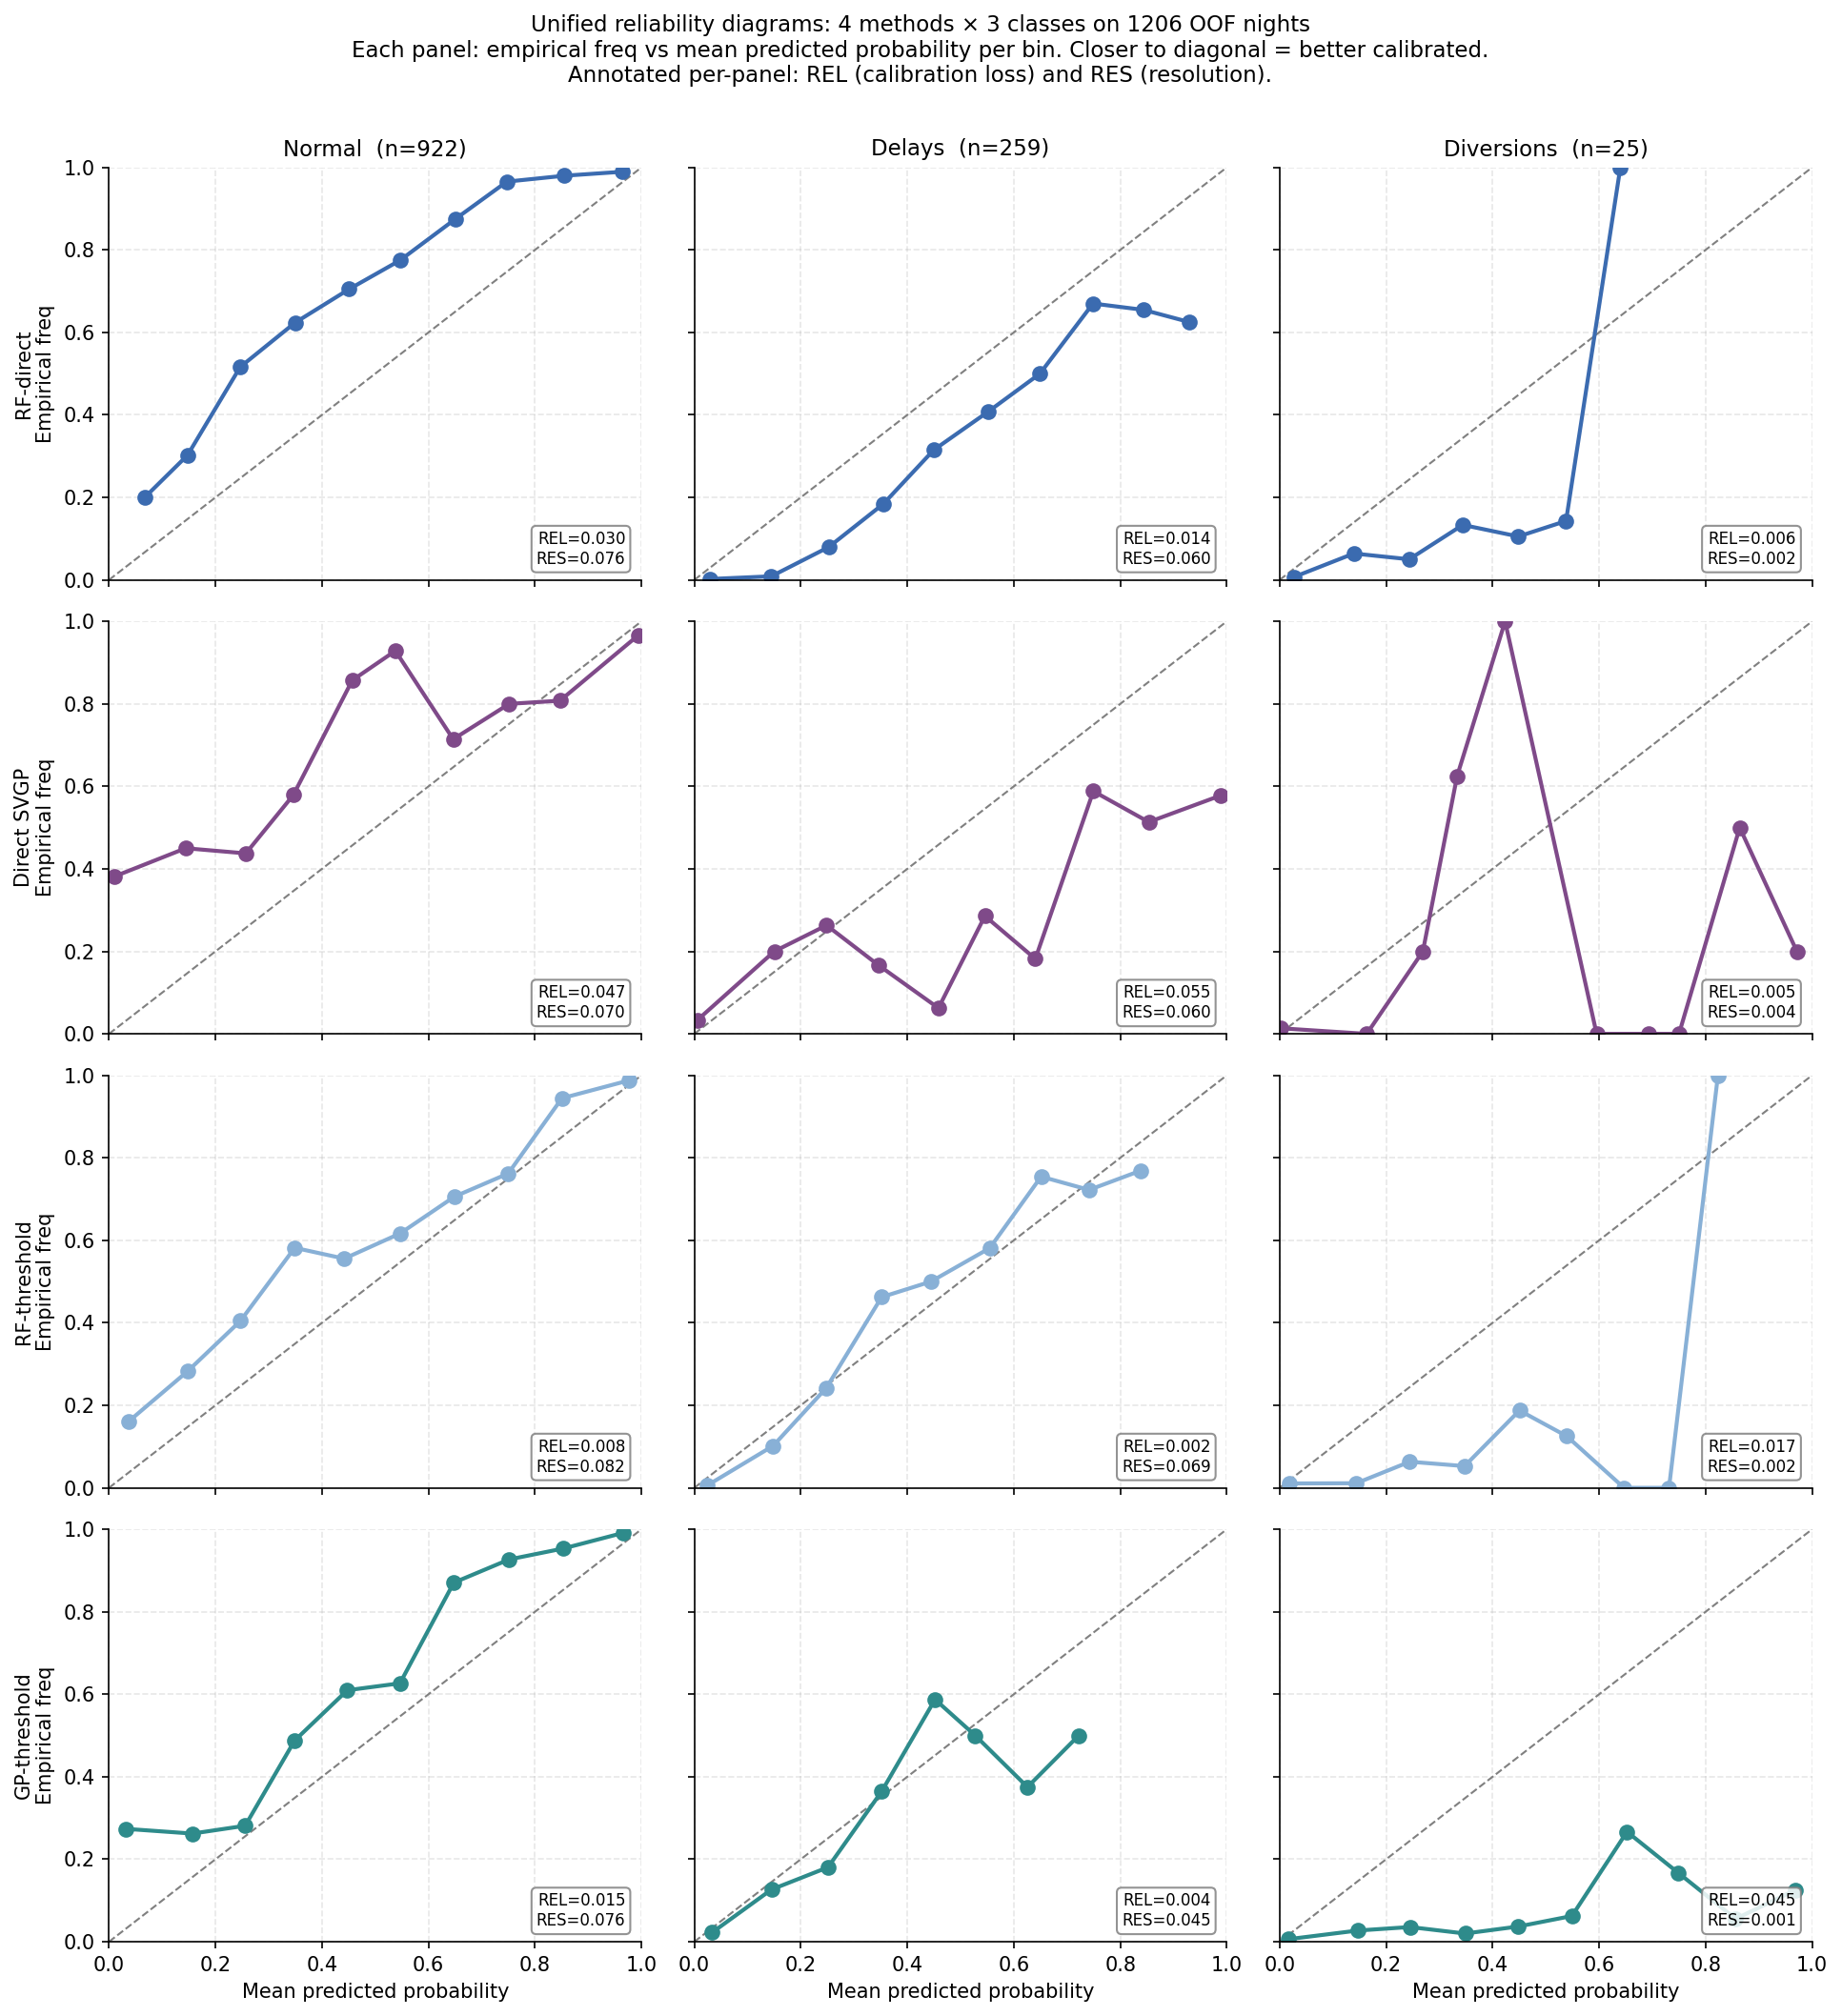

In [7]:
metrics, oof = load_data()
p = plot_unified_reliability(metrics, oof)
print(f'Wrote {p}')
display(Image(filename=str(p)))

**Figure 2 — Brier decomposition:** per-method REL (left) and RES (right), broken down by class. RF-threshold lowest REL and highest RES simultaneously.

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step7_brier_decomposition.png


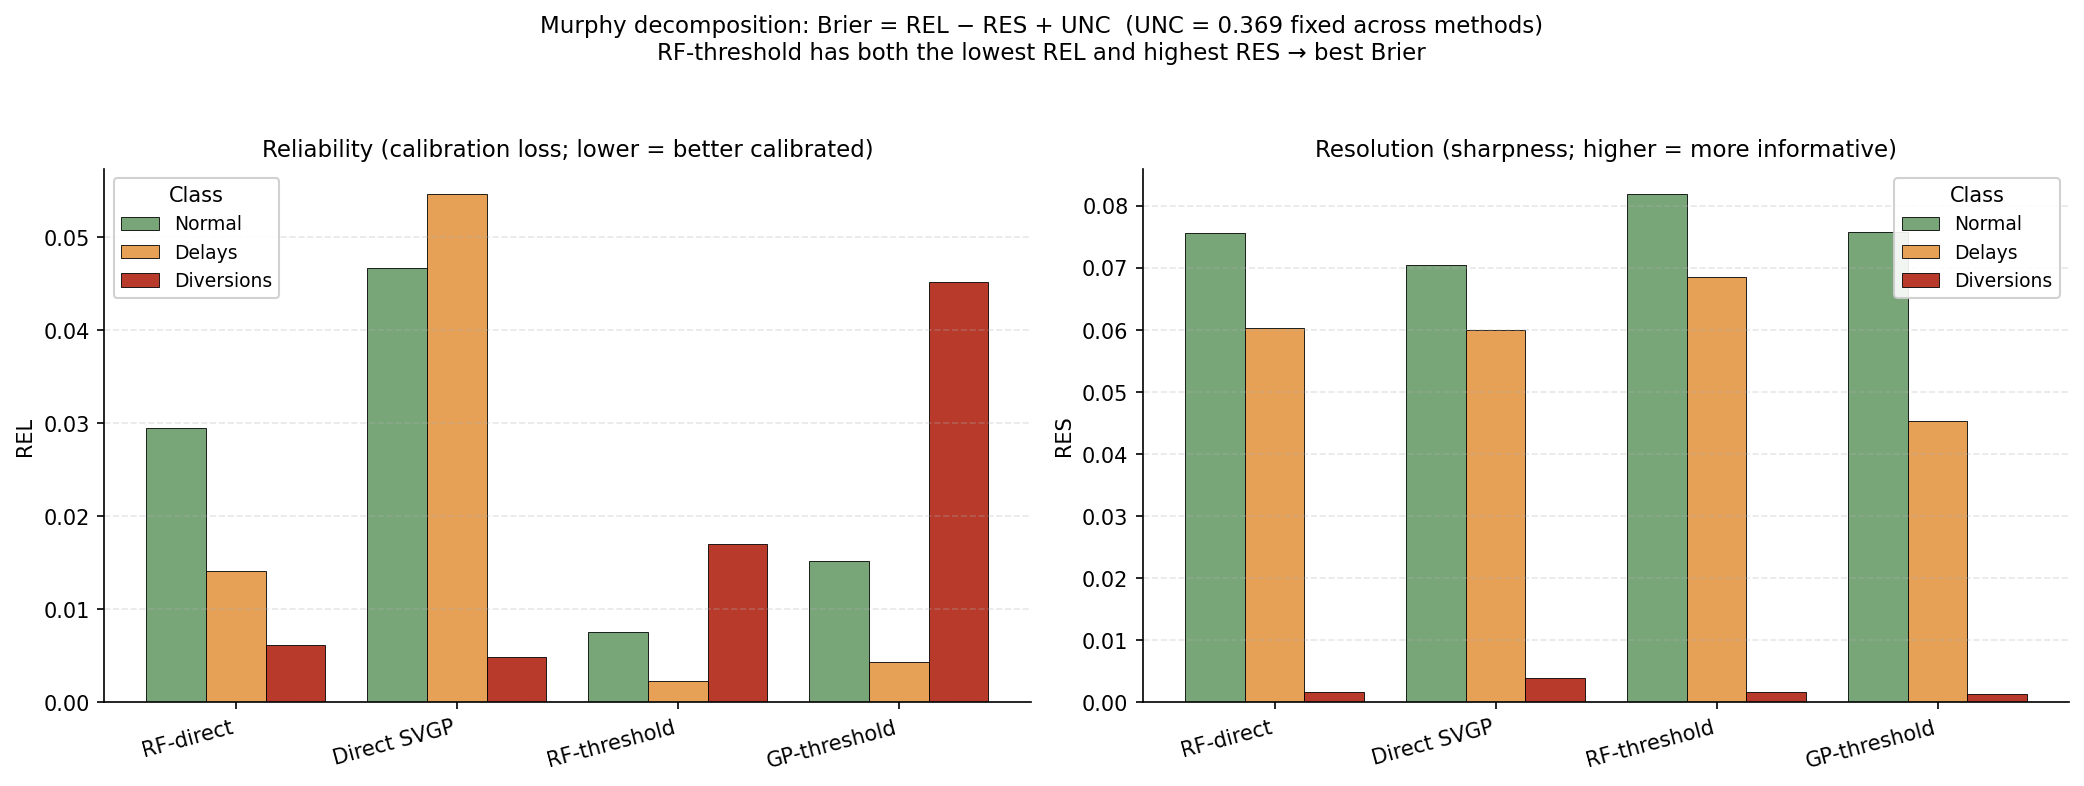

In [8]:
metrics, oof = load_data()
p = plot_brier_decomposition(metrics)
print(f'Wrote {p}')
display(Image(filename=str(p)))

**Figure 3 — Operational decision curve:** Vickers net benefit vs alert threshold. Where each method beats both treat-all (alert every night) and treat-none (no alerts) is its useful operational regime.

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step7_net_benefit.png


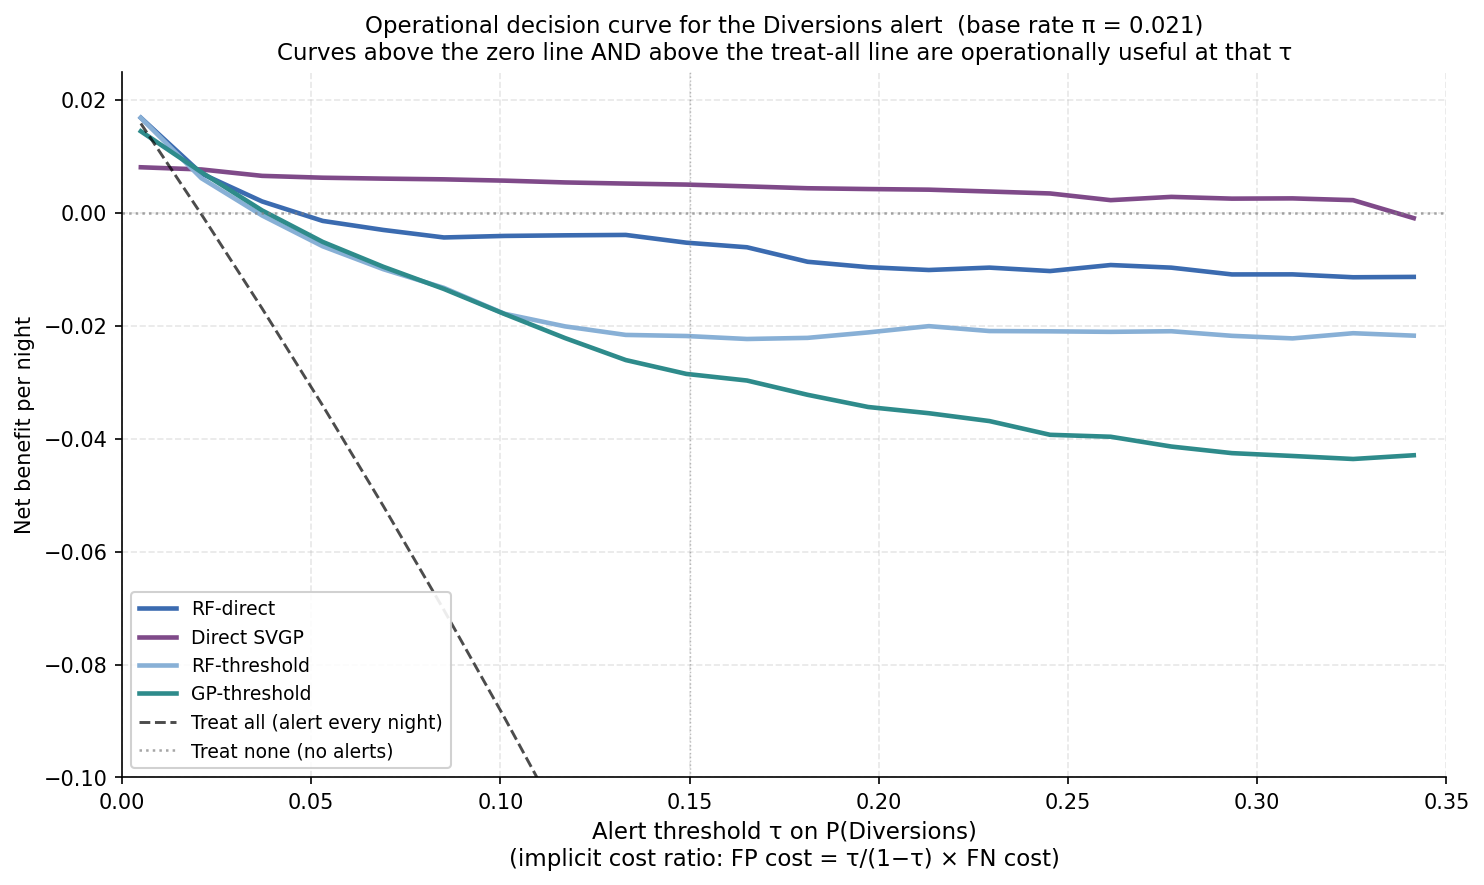

In [9]:
metrics, oof = load_data()
p = plot_net_benefit(metrics)
print(f'Wrote {p}')
display(Image(filename=str(p)))

**Figure 4 — Summary heatmap:** methods × metrics with per-column rank. Visual ranking of which method dominates which metric.

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step7_summary_heatmap.png


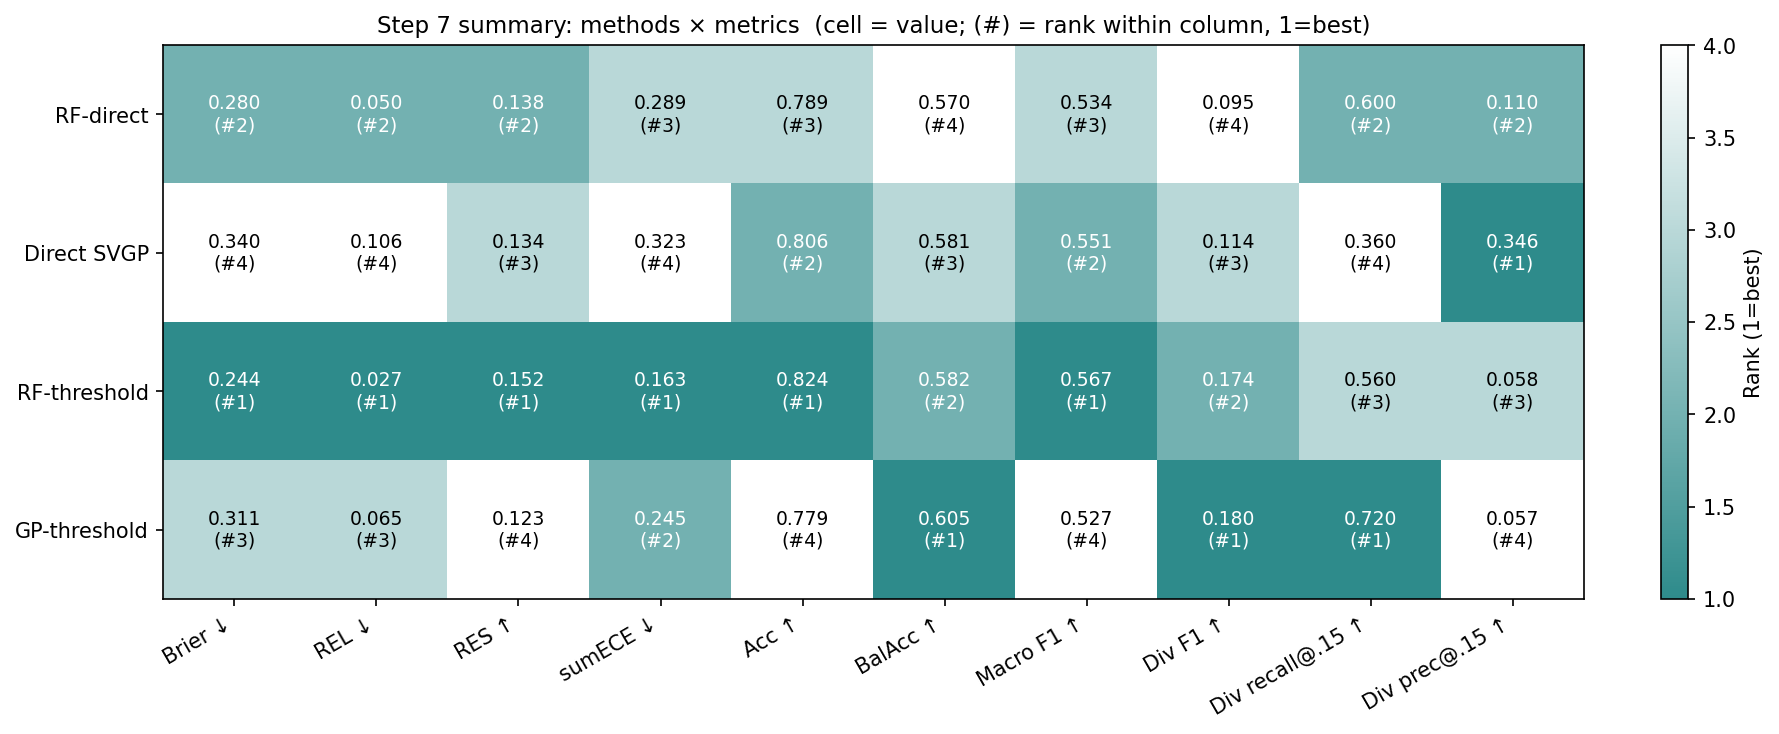

In [10]:
metrics, oof = load_data()
p = plot_summary_heatmap(metrics)
print(f'Wrote {p}')
display(Image(filename=str(p)))

## 5. Paper writing checklist (Step 8)

Empirical content is now complete. The remaining work is the writeup — 6-page paper + GitHub repo for STW7085CEM Task 1 by June 1, 2026.

**Structure suggestion (6 pages):**
1. **Introduction** (~½ page): VNKT fog problem; the calibration-vs-accuracy thesis for safety-critical forecasting.
2. **Data and methods** (~1½ pages): METAR pipeline, feature engineering, forward-chaining CV, the four predictor models (RF, GP regression with Matérn-5/2 ARD, direct SVGP classifier, threshold-derivation method).
3. **Results** (~2 pages): use the Step 7 summary table as the centrepiece; bring in regression PI coverage (Step 5), classification reliability (Step 6/7), and the operational decision curve (Step 7).
4. **Discussion** (~1 page): the two findings (methodology vs posterior choice), GP-ARD physical interpretability (dewpoint depression and overnight cooling), honest limitations (RF wins aggregate Brier, GP wins rare-class detection — choose the model that matches your operational concern), Gaussian-in-metres caveat for RF-threshold, the unphysical negative-visibility issue.
5. **Conclusion + future work** (~½ page): real-time deployment, longer training history, calibrated rare-class classifiers via post-hoc methods.

**Figures budget (6-page paper typically allows 3–4 figures):**
- Figure A: Step 5 calibration curve (regression PI coverage GP vs RF) — the regression result
- Figure B: Step 7 unified reliability (4×3 grid) — the classification result
- Figure C: Step 7 net-benefit decision curve — the operational framing
- Optional Figure D: Step 5 ARD lengthscales — the scientific-interpretability result

**Tables budget (typically 1–2 tables):**
- Table 1: Step 7 summary (all four methods, all headline metrics)
- Optional Table 2: Step 7 per-class decomposition

Ready when you are.